In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

In [26]:
#Optional for disabling warnings
import sys
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

In [27]:
#Set figure resolution to 300dpi
import matplotlib as mpl
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [28]:
# Load the dataset
df = pd.read_excel(r'./Summer 26 Lab 1_yellowover25_orangeunder25.xlsx', index_col=0)
df


,rest,post-ex,1,2,3
Individual,,,,,
1,60,76,62,62,60
2,60,80,60,60,60
3,72,80,76,74,72
4,68,68,60,64,68
5,68,80,64,62,64
6,56,80,66,56,56
7,64,72,68,64,64
8,58,68,60,58,58
9,60,70,64,60,60


In [29]:

# Transpose to have individuals as columns
dft = df.transpose()
dft

Individual,1,2,3,4,5,6,7,8,9,10,11
rest,60,60,72,68,68,56,64,58,60,60,64
post-ex,76,80,80,68,80,80,72,68,70,68,48
1,62,60,76,60,64,66,68,60,64,62,48
2,62,60,74,64,62,56,64,58,60,58,52
3,60,60,72,68,64,56,64,58,60,56,52


In [30]:
# Rename "Sit" and "Stand" to numeric labels
dft.rename(index={'rest': '-1', 'post-ex': '0'}, inplace=True)
dft

Individual,1,2,3,4,5,6,7,8,9,10,11
-1,60,60,72,68,68,56,64,58,60,60,64
0,76,80,80,68,80,80,72,68,70,68,48
1,62,60,76,60,64,66,68,60,64,62,48
2,62,60,74,64,62,56,64,58,60,58,52
3,60,60,72,68,64,56,64,58,60,56,52


In [31]:
# Convert index to integers for consistency
dft.index = dft.index.astype(int)

# Define the group mappings
group_mapping = {
    1: 'Over_25', 2: 'Over_25', 9: 'Over_25', 11: 'Over_25',
    3: 'Under_25', 4: 'Under_25', 5: 'Under_25', 6: 'Under_25', 7: 'Under_25', 8: 'Under_25', 10: 'Under_25'
}

# Transpose to assign groups to individuals
dft_t = dft.transpose()

# Add a 'Group' column
dft_t['Group'] = [group_mapping[int(col)] for col in dft_t.index]
dft_t

,-1,0,1,2,3,Group
Individual,,,,,,
1,60,76,62,62,60,Over_25
2,60,80,60,60,60,Over_25
3,72,80,76,74,72,Under_25
4,68,68,60,64,68,Under_25
5,68,80,64,62,64,Under_25
6,56,80,66,56,56,Under_25
7,64,72,68,64,64,Under_25
8,58,68,60,58,58,Under_25
9,60,70,64,60,60,Over_25


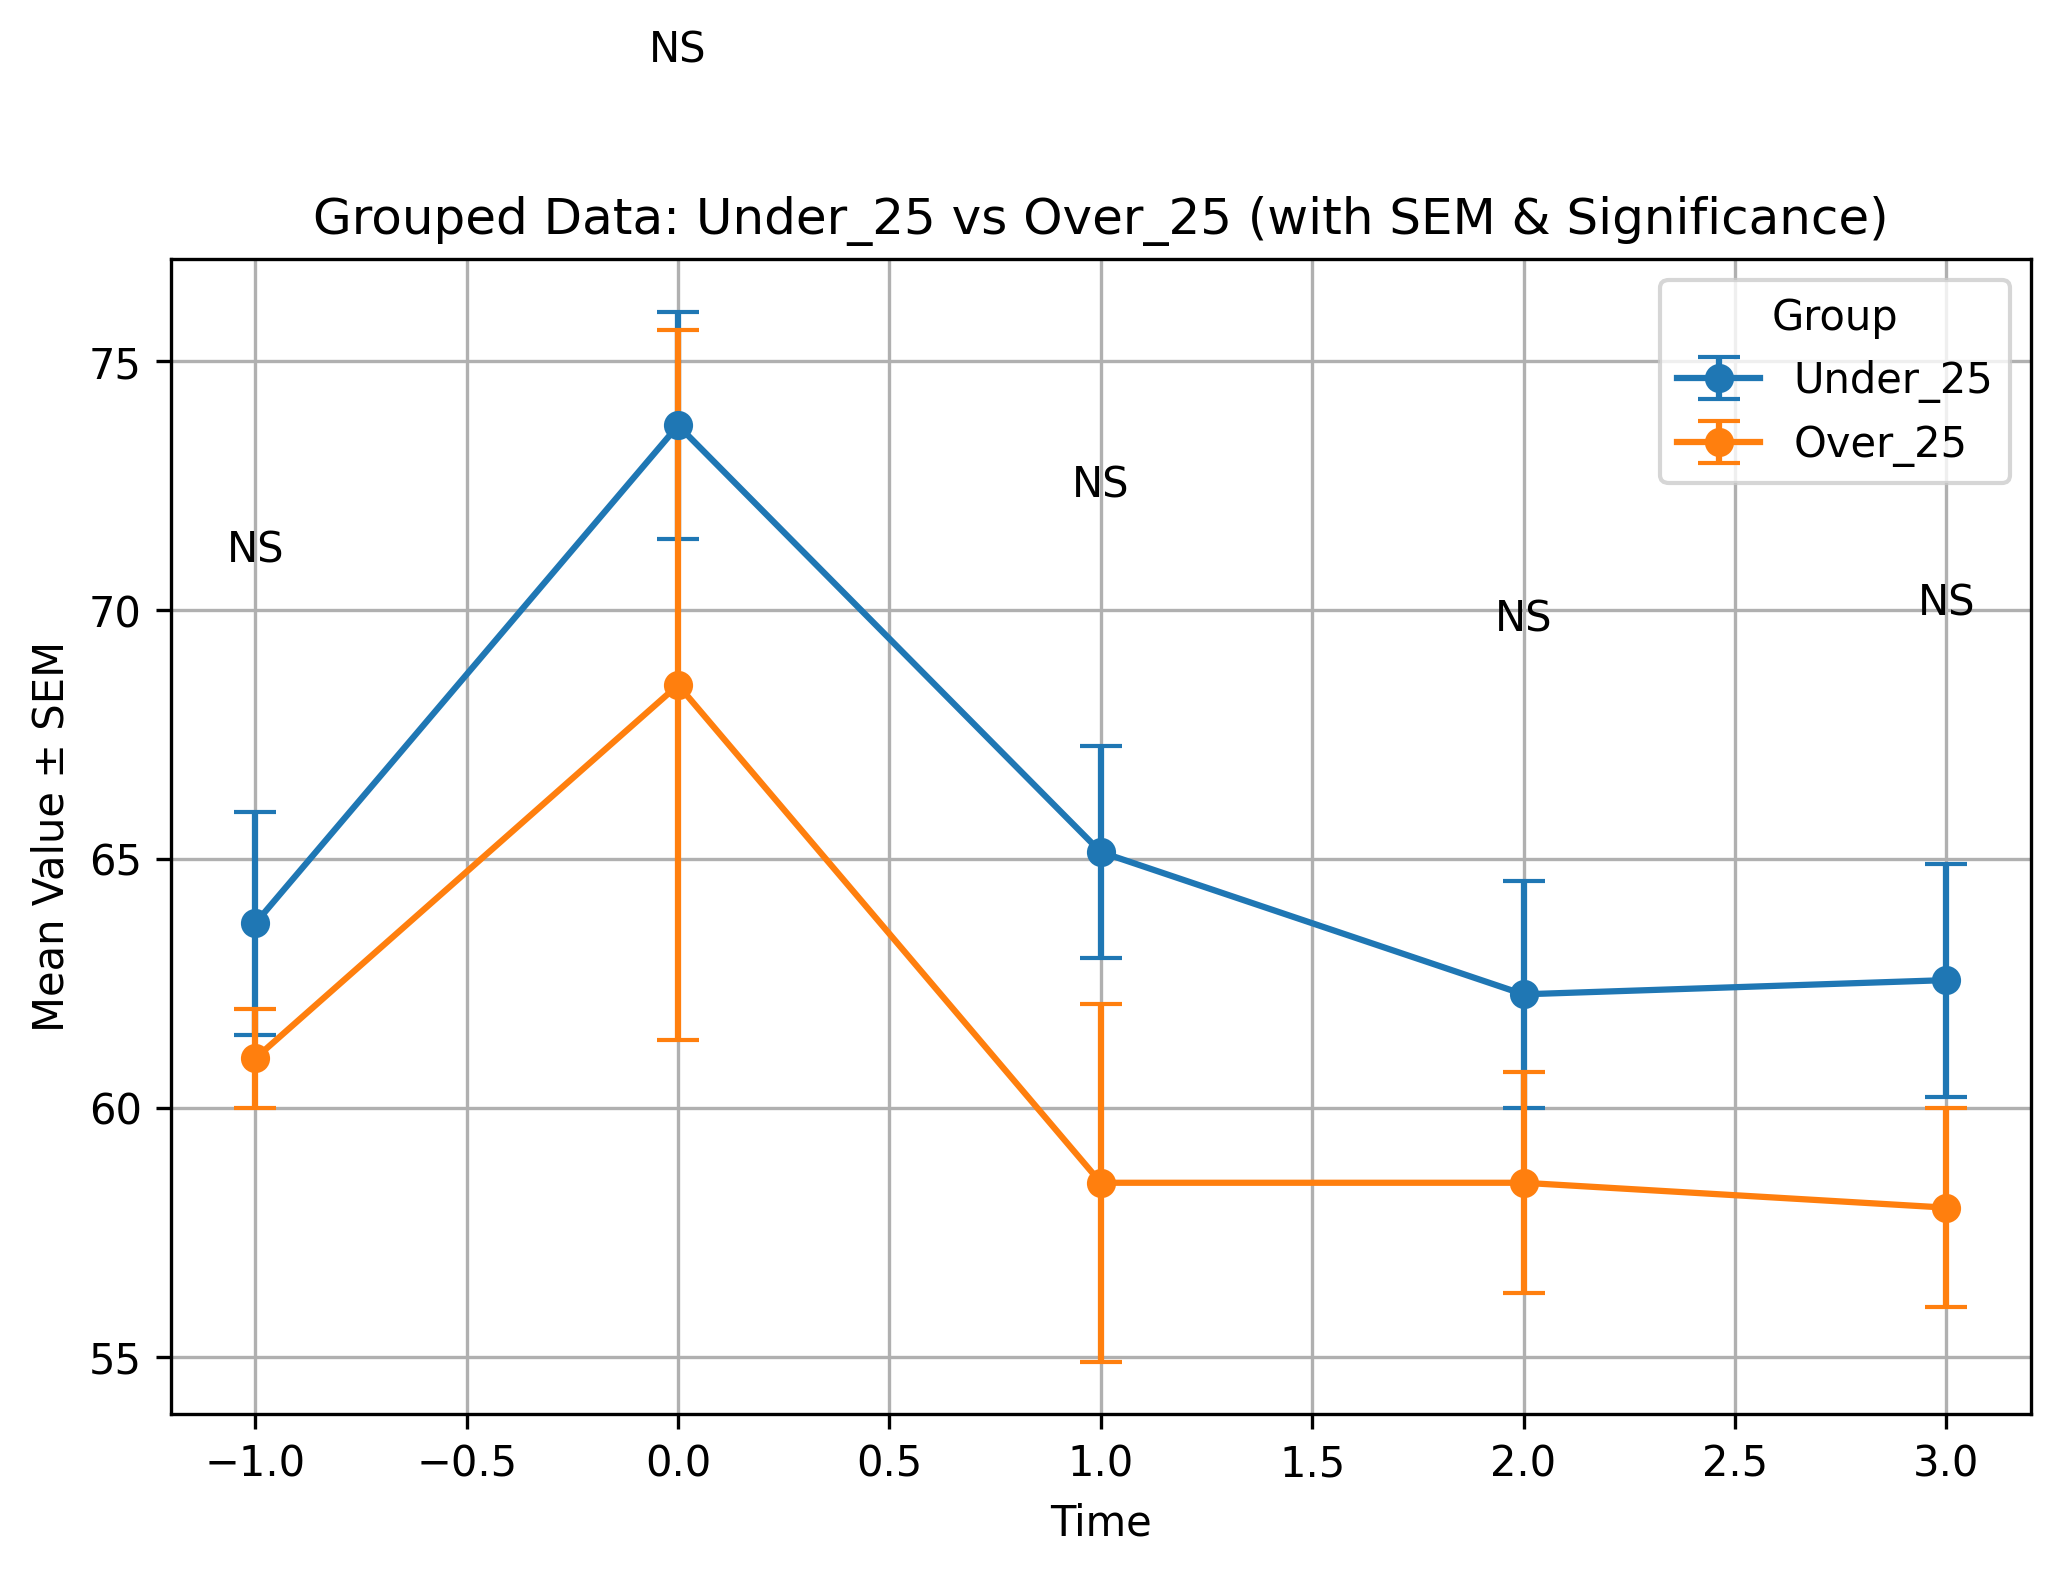

,Time,p-value,Significance
0,-1,0.301331,NS
1,0,0.528470,NS
2,1,0.170933,NS
3,2,0.267976,NS
4,3,0.172744,NS


In [33]:
# Enter the exact group names found in the "Group" column
group1 = 'Under_25'
group2 = 'Over_25'

# Compute mean and standard deviation for each group
group_means = dft_t.groupby('Group').mean().transpose()
group_stds = dft_t.groupby('Group').std().transpose()

# Number of samples in each group
N_group1 = sum(dft_t['Group'] == group1)
N_group2 = sum(dft_t['Group'] == group2)

# Compute standard error of the mean (SEM)
group_sems = group_stds.copy()
group_sems[group1] /= np.sqrt(N_group1)
group_sems[group2] /= np.sqrt(N_group2)

# Perform t-tests at each time point
time_points = group_means.index
p_values = []

for t in time_points:
    group1_values = dft_t[dft_t['Group'] == group1][t]
    group2_values = dft_t[dft_t['Group'] == group2][t]

    t_stat, p = ttest_ind(
        group1_values,
        group2_values,
        equal_var=False
    )

    p_values.append(p)

# Determine significance labels
significance_labels = []

for p in p_values:
    if p < 0.001:
        significance_labels.append("***")  # Highly significant
    elif p < 0.01:
        significance_labels.append("**")   # Significant
    elif p < 0.05:
        significance_labels.append("*")    # Marginal significance
    else:
        significance_labels.append("NS")   # Not significant

# Plot the data with SEM error bars
plt.figure(figsize=(8, 5))

for group in [group1, group2]:
    plt.errorbar(
        time_points,
        group_means[group],
        yerr=group_sems[group],
        capsize=5,
        marker='o',
        label=group,
        linestyle='-'
    )

# Annotate significance labels at each time point
for x, p_label in zip(time_points, significance_labels):
    annotation_height = max(
        group_means.loc[x, group1] + group_sems.loc[x, group1],
        group_means.loc[x, group2] + group_sems.loc[x, group2]
    )

    plt.text(
        x,
        annotation_height + 5,
        p_label,
        ha='center',
        fontsize=10,
        color='black'
    )

# Format the plot
plt.xlabel("Time")
plt.ylabel("Mean Value ± SEM")
plt.title(f"Grouped Data: {group1} vs {group2} (with SEM & Significance)")
plt.legend(title="Group")
plt.grid(True)

# Show the plot
plt.show()

# Display p-values for reference
p_value_table = pd.DataFrame({
    'Time': time_points,
    'p-value': p_values,
    'Significance': significance_labels
})

from IPython.display import display
display(p_value_table)